In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm

### DCE Futures Series Analysis

### Source-domain data $D_S$, Stage A pre-training)

In [2]:
df_source_features = pd.DataFrame(
    index=pd.date_range(
        start="1954-01-04",
        end=pd.Timestamp.today().normalize(),
        freq="D",
        name="date"
    )
)

df_source_features

""
date
1954-01-04
1954-01-05
1954-01-06
1954-01-07
1954-01-08
...
2026-08-21
2026-08-22
2026-08-23


Global commodity benchmark index: S&P GSCI (Daily, from 31.12.1969)

In [3]:
data_folder = Path("../2_data/2.1_raw/Capital IQ")
files = sorted(data_folder.glob("*.csv"))

frames = []

for file in files:
    file_df = pd.read_csv(file)

    # Remove accidental whitespace from column names
    file_df.columns = file_df.columns.str.strip()

    # Convert Date strings such as 12/31/1969
    file_df["Date"] = pd.to_datetime(
        file_df["Date"],
        format="%m/%d/%Y",
        errors="coerce"
    )

    frames.append(file_df[["Date", "Close"]])

if not frames:
    raise FileNotFoundError(
        f"No CSV files found in: {data_folder.resolve()}"
    )

gsci = pd.concat(frames, ignore_index=True)

# Clean and index the combined series
gsci = (
    gsci
    .dropna(subset=["Date"])
    .drop_duplicates(subset=["Date"], keep="last")
    .set_index("Date")
    .sort_index()
)

# Ensure the target DataFrame also has a DatetimeIndex
df_source_features.index = pd.to_datetime(df_source_features.index)
df_source_features.index.name = "Date"

# Assignment aligns the values by date
df_source_features["GSCI"] = gsci["Close"]

df_source_features

,GSCI
Date,
1954-01-04,NaN
1954-01-05,NaN
1954-01-06,NaN
1954-01-07,NaN
1954-01-08,NaN
...,...
2026-08-21,717.22
2026-08-22,NaN
2026-08-23,NaN


Federal Funds Effective Rate: DFF (Daily, from 01.07.1954)

In [4]:
path = Path("../2_data/2.1_raw/FRED/DFF.xlsx")

dff = pd.read_excel(
    path,
    sheet_name="Daily, 7-Day",
    usecols=["observation_date", "DFF"]
)

dff["observation_date"] = pd.to_datetime(dff["observation_date"])

dff = (
    dff
    .dropna(subset=["observation_date"])
    .drop_duplicates(subset=["observation_date"], keep="last")
    .set_index("observation_date")
    .sort_index()
)

# Make sure the existing index is also datetime
df_source_features.index = pd.to_datetime(df_source_features.index)
df_source_features.index.name = "Date"

# Pandas matches the rows by date
df_source_features["DFF"] = dff["DFF"]

df_source_features

,GSCI,DFF
Date,,
1954-01-04,NaN,NaN
1954-01-05,NaN,NaN
1954-01-06,NaN,NaN
1954-01-07,NaN,NaN
1954-01-08,NaN,NaN
...,...,...
2026-08-21,717.22,NaN
2026-08-22,NaN,NaN
2026-08-23,NaN,NaN


3-Month Treasury Bill Secondary Market Rate: DTB3 (Daily, from 04.01.1954)

In [5]:
path = Path("../2_data/2.1_raw/FRED/DTB3.xlsx")

dtb3 = pd.read_excel(
    path,
    sheet_name="Daily",
    usecols=["observation_date", "DTB3"]
)

dtb3["observation_date"] = pd.to_datetime(dtb3["observation_date"])

dtb3 = (
    dtb3
    .dropna(subset=["observation_date"])
    .drop_duplicates(subset=["observation_date"], keep="last")
    .set_index("observation_date")
    .sort_index()
)

# Make sure the existing index is also datetime
df_source_features.index = pd.to_datetime(df_source_features.index)
df_source_features.index.name = "Date"

# Pandas matches the rows by date
df_source_features["DTB3"] = dtb3["DTB3"]

df_source_features

,GSCI,DFF,DTB3
Date,,,
1954-01-04,NaN,NaN,1.33
1954-01-05,NaN,NaN,1.28
1954-01-06,NaN,NaN,1.28
1954-01-07,NaN,NaN,1.31
1954-01-08,NaN,NaN,1.31
...,...,...,...
2026-08-21,717.22,NaN,NaN
2026-08-22,NaN,NaN,NaN
2026-08-23,NaN,NaN,NaN


Nominal Broad U.S. Dollar Index: DTWEXBGS (Daily, from 02.01.2006)

In [6]:
path = Path("../2_data/2.1_raw/FRED/DTWEXBGS.xlsx")

dtwexbgs = pd.read_excel(
    path,
    sheet_name="Daily",
    usecols=["observation_date", "DTWEXBGS"]
)

dtwexbgs["observation_date"] = pd.to_datetime(dtwexbgs["observation_date"])

dtwexbgs = (
    dtwexbgs
    .dropna(subset=["observation_date"])
    .drop_duplicates(subset=["observation_date"], keep="last")
    .set_index("observation_date")
    .sort_index()
)

# Make sure the existing index is also datetime
df_source_features.index = pd.to_datetime(df_source_features.index)
df_source_features.index.name = "Date"

# Pandas matches the rows by date
df_source_features["DTWEXBGS"] = dtwexbgs["DTWEXBGS"] 

df_source_features

,GSCI,DFF,DTB3,DTWEXBGS
Date,,,,
1954-01-04,NaN,NaN,1.33,NaN
1954-01-05,NaN,NaN,1.28,NaN
1954-01-06,NaN,NaN,1.28,NaN
1954-01-07,NaN,NaN,1.31,NaN
1954-01-08,NaN,NaN,1.31,NaN
...,...,...,...,...
2026-08-21,717.22,NaN,NaN,NaN
2026-08-22,NaN,NaN,NaN,NaN
2026-08-23,NaN,NaN,NaN,NaN


CBOE Volatility Index: VIXCLS (Daily, from 02.01.1990)

In [7]:
path = Path("../2_data/2.1_raw/FRED/VIXCLS.xlsx") 

vixcls = pd.read_excel(
    path,
    sheet_name="Daily, Close",
    usecols=["observation_date", "VIXCLS"]
)

vixcls["observation_date"] = pd.to_datetime(vixcls["observation_date"])

vixcls = (
    vixcls
    .dropna(subset=["observation_date"])
    .drop_duplicates(subset=["observation_date"], keep="last")
    .set_index("observation_date")
    .sort_index()
)

# Make sure the existing index is also datetime
df_source_features.index = pd.to_datetime(df_source_features.index)
df_source_features.index.name = "Date"

# Pandas matches the rows by date
df_source_features["VIXCLS"] = vixcls["VIXCLS"]

df_source_features

,GSCI,DFF,DTB3,DTWEXBGS,VIXCLS
Date,,,,,
1954-01-04,NaN,NaN,1.33,NaN,NaN
1954-01-05,NaN,NaN,1.28,NaN,NaN
1954-01-06,NaN,NaN,1.28,NaN,NaN
1954-01-07,NaN,NaN,1.31,NaN,NaN
1954-01-08,NaN,NaN,1.31,NaN,NaN
...,...,...,...,...,...
2026-08-21,717.22,NaN,NaN,NaN,NaN
2026-08-22,NaN,NaN,NaN,NaN,NaN
2026-08-23,NaN,NaN,NaN,NaN,NaN


In [8]:
df_source_features["VIXCLS"].notna().sum()

np.int64(9256)

In [9]:
output_path = Path("../2_data/2.2_processed/source_features.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)

df_source_features.to_csv(output_path, index=True)

print(f"Saved to: {output_path.resolve()}")

Saved to: C:\Users\Leo\PycharmProjects\Thesis Project\2_data\2.2_processed\source_features.csv


In [10]:
def plot_time_series(
    df,
    column,
    output_path,
    label=None,
    color="green",
    start=None,
    end=None,
    ylabel=None,
    x_step_years=10,
    show=True
):
    series = df[column].copy()
    series.index = pd.to_datetime(series.index)
    series = series.sort_index()

    if start is not None:
        series = series.loc[pd.Timestamp(start):]

    if end is not None:
        series = series.loc[:pd.Timestamp(end)]

    series = series.dropna()

    if series.empty:
        raise ValueError(
            f"Column '{column}' contains no observations "
            "for the selected period."
        )

    x = series.index
    y = series.to_numpy()

    cm = 1 / 2.54

    fig, ax = plt.subplots(
        figsize=(7.8 * cm, 4.5 * cm),
        layout="constrained"
    )

    ax.plot(
        x,
        y,
        color=color,
        linewidth=1,
        label=label or column
    )

    ax.fill_between(
        x,
        y,
        0,
        color=color,
        alpha=0.1
    )

    ax.set_xlabel("Time")

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    ax.legend(frameon=False)
    ax.grid(False)

    ax.spines["bottom"].set_position(("data", 0))
    ax.spines["left"].set_position(("axes", 0))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.xaxis.set_ticks_position("bottom")
    ax.yaxis.set_ticks_position("left")

    ax.tick_params(
        axis="both",
        which="major",
        direction="inout",
        length=4,
        width=0.8
    )

    # Control the spacing of x-axis ticks
    if x_step_years is not None:
        ax.xaxis.set_major_locator(
            mdates.YearLocator(base=x_step_years)
        )
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%Y")
        )
    else:
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(
            mdates.ConciseDateFormatter(locator)
        )

    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(bottom=min(0, y.min()))

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(
        output_path,
        bbox_inches="tight"
    )

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

In [11]:
font_folder = Path(r"C:\USERS\LEO\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS")

for font_file in [
    "CMUNRM.TTF",  # Roman
    "CMUNTI.TTF",  # Italic
    "CMUNBX.TTF",  # Bold
    "CMUNBI.TTF",  # Bold Italic
]:
    fm.fontManager.addfont(str(font_folder / font_file))

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["CMU Serif"],

    "mathtext.fontset": "cm",

    "axes.unicode_minus": False,
})

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

webf NOT subset; don't know how to subset; dropped


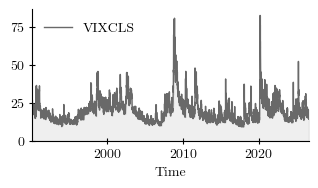

(<Figure size 307.087x177.165 with 1 Axes>, <Axes: xlabel='Time'>)

In [16]:
plot_time_series(
    df=df_source_features,
    column="VIXCLS",
    color="dimgray",
    label=None,
    output_path="../1_latex/1.5_figures/test figures/vixcls.pdf"
)

webf NOT subset; don't know how to subset; dropped


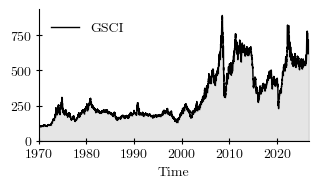

(<Figure size 307.087x177.165 with 1 Axes>, <Axes: xlabel='Time'>)

In [13]:
plot_time_series(
    df=df_source_features,
    column="GSCI",
    color="black",
    output_path="../1_latex/1.5_figures/test figures/gsci.pdf"
)

webf NOT subset; don't know how to subset; dropped


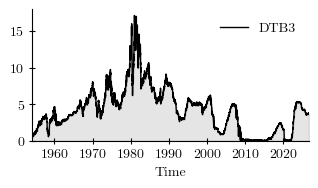

(<Figure size 307.087x177.165 with 1 Axes>, <Axes: xlabel='Time'>)

In [14]:
plot_time_series(
    df=df_source_features,
    column="DTB3",
    color="black",
    output_path="../1_latex/1.5_figures/test figures/dtb3.pdf"
)

webf NOT subset; don't know how to subset; dropped


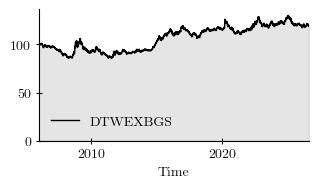

(<Figure size 307.087x177.165 with 1 Axes>, <Axes: xlabel='Time'>)

In [15]:
plot_time_series(
    df=df_source_features,
    column="DTWEXBGS",
    color="black",
    output_path="../1_latex/1.5_figures/test figures/dtwexbgs.pdf"
)